# Modelos de Difusão Latente (Latent Diffusion Models)

Neste notebook, exploraremos os **Latent Diffusion Models (LDMs)**, a arquitetura que está no coração de sistemas modernos de geração de imagens como o **Stable Diffusion**. Nos notebooks anteriores, aplicamos o processo de difusão diretamente sobre os pixels das imagens. Embora funcional, essa abordagem é computacionalmente cara: a rede de desruído precisa operar centenas de vezes sobre tensores de alta dimensionalidade, e grande parte desse esforço é gasto modelando detalhes de alta frequência que são perceptualmente irrelevantes.

A ideia central dos LDMs é separar o problema em dois estágios:

1. **Compressão Perceptual (VAE):** Treinamos um **Autoencoder Variacional (VAE)** que mapeia uma imagem $x \in \mathbb{R}^{1 \times 32 \times 32}$ para uma representação latente compacta $z = \mathcal{E}(x)$, e um decodificador $\mathcal{D}$ capaz de reconstruir a imagem a partir do latente, $\hat{x} = \mathcal{D}(z) \approx x$. É esta a escolha do Stable Diffusion: a regularização do VAE produz um espaço latente suave, ideal para a difusão.
2. **Difusão no Espaço Latente:** Em vez de aplicar o DDPM sobre os pixels, aplicamos o processo de difusão (forward e reverso) sobre os latentes $z$. Após a amostragem produzir um latente limpo $z_0$, basta uma única passagem pelo decodificador $\mathcal{D}$ para obter a imagem final.

Como o espaço latente possui dimensionalidade muito menor que o espaço de pixels, a rede de desruído se torna menor, o treinamento mais rápido e a amostragem mais barata — tudo isso sem perda significativa de qualidade visual. Ao final, implementaremos também o **Classifier-Free Guidance (CFG)** no espaço latente, permitindo controlar qual dígito é gerado.

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo ativo: {device}")

Dispositivo ativo: cuda


## Preparação dos Dados

Utilizaremos o dataset **MNIST** (dígitos manuscritos de 0 a 9). As imagens serão redimensionadas para $32 \times 32$ (facilitando as divisões sucessivas por 2 nas redes convolucionais) e normalizadas para o intervalo $[-1, 1]$. Para garantir um treinamento rápido, selecionaremos um subconjunto de 10.000 imagens.

In [3]:
# Hiperparâmetros de dados
batch_size = 128

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normaliza de [0, 1] para [-1, 1]
])

# Carregar MNIST e obter subconjunto
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_dataset = Subset(train_dataset_full, range(10000))
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"Subconjunto do MNIST carregado: {len(train_dataset)} imagens.")

Subconjunto do MNIST carregado: 10000 imagens.


## Estágio 1: Autoencoder Variacional (VAE)

O primeiro estágio de um LDM é um **Autoencoder Variacional (VAE)** que aprende a comprimir as imagens em um **espaço latente espacial**. É exatamente esta a escolha feita pelo Stable Diffusion: em vez de um autoencoder determinístico, usa-se um VAE porque seu termo de regularização produz um espaço latente **suave e contínuo**, muito mais adequado para que o modelo de difusão opere em seguida. Diferente do VAE do notebook de VAEs (que produzia um vetor latente achatado), aqui o latente mantém uma estrutura espacial de "mini-imagem" com múltiplos canais, pois o segundo estágio usará uma U-Net convolucional sobre esses latentes.

As dimensões de cada etapa são:

- **Encoder ($\mathcal{E}$):** recebe $x \in \mathbb{R}^{B \times 1 \times 32 \times 32}$ e reduz a resolução com convoluções de *stride* 2. Em vez de produzir um único latente, produz **dois mapas** de mesma forma $B \times 4 \times 8 \times 8$: a média $\mu$ e a log-variância $\log \sigma^2$ da distribuição posterior $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$.
- **Decoder ($\mathcal{D}$):** recebe um latente amostrado $z \in \mathbb{R}^{B \times 4 \times 8 \times 8}$ e aumenta a resolução com convoluções transpostas, produzindo $\hat{x} \in \mathbb{R}^{B \times 1 \times 32 \times 32}$. A última camada usa **Tanh**, pois as imagens estão normalizadas em $[-1, 1]$.

Para amostrar $z$ de forma diferenciável, usamos o **truque de reparametrização**:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

Onde $\sigma = \exp(\tfrac{1}{2}\log\sigma^2)$. O VAE é treinado maximizando o ELBO, ou equivalentemente minimizando a soma de um termo de reconstrução e um termo de regularização KL:

$$\mathcal{L}_{VAE} = \underbrace{\mathbb{E}_{q_\phi(z|x)}\left[\| x - \mathcal{D}(z) \|^2\right]}_{\text{reconstrução}} + \beta_{KL} \underbrace{D_{KL}\!\left(q_\phi(z|x) \,\|\, \mathcal{N}(0, \mathbf{I})\right)}_{\text{regularização}}$$

Onde $\beta_{KL}$ pondera a força da regularização. Em LDMs usamos um $\beta_{KL}$ pequeno: queremos reconstruções nítidas (a fidelidade do decoder é o **teto superior** da qualidade do LDM), mas ainda assim com um espaço latente bem comportado. A divergência KL para um posterior Gaussiano diagonal tem forma fechada:

$$D_{KL} = -\frac{1}{2} \sum_{j} \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_channels=4, hidden_dim=32):
        super().__init__()

        # Tronco do encoder (compartilhado entre as cabeças mu e logvar)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, hidden_dim, 3, stride=2, padding=1),               # Saída: B x 32 x 16 x 16
            nn.GroupNorm(8, hidden_dim),
            nn.GELU(),

            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, stride=2, padding=1),  # Saída: B x 64 x 8 x 8
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),

            nn.Conv2d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),        # Saída: B x 64 x 8 x 8
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),
        )

        # Cabeças que projetam para a média e a log-variância do posterior
        self.conv_mu = nn.Conv2d(hidden_dim * 2, latent_channels, 3, padding=1)      # Saída: B x 4 x 8 x 8
        self.conv_logvar = nn.Conv2d(hidden_dim * 2, latent_channels, 3, padding=1)  # Saída: B x 4 x 8 x 8

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, hidden_dim * 2, 3, padding=1),                # Saída: B x 64 x 8 x 8
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),

            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, 4, stride=2, padding=1),  # Saída: B x 32 x 16 x 16
            nn.GroupNorm(8, hidden_dim),
            nn.GELU(),

            nn.ConvTranspose2d(hidden_dim, hidden_dim, 4, stride=2, padding=1),      # Saída: B x 32 x 32 x 32
            nn.GroupNorm(8, hidden_dim),
            nn.GELU(),

            nn.Conv2d(hidden_dim, 1, 3, padding=1),                                  # Saída: B x 1 x 32 x 32
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.conv_mu(h), self.conv_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Treinamento do VAE

Treinaremos o VAE por algumas épocas com o otimizador **Adam**, minimizando a soma do erro de reconstrução (MSE) e da divergência KL ponderada por $\beta_{KL}$. Para acompanhar o equilíbrio entre os dois objetivos, registraremos separadamente o termo de reconstrução e o termo KL ao longo do treinamento. Como o modelo é pequeno e o dataset é reduzido, o treinamento leva poucos minutos.

In [5]:
# Instanciar o VAE, otimizador e o peso do termo KL
latent_channels = 4
beta_kl = 1e-4  # peso pequeno: prioriza reconstruções nítidas (típico em LDMs)

vae = VAE(latent_channels=latent_channels).to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

Iniciando treinamento do VAE...


VAE - Época 15/15: 100%|██████████| 78/78 [00:03<00:00, 23.18it/s, kl=1.28e+3, recon=2.82]


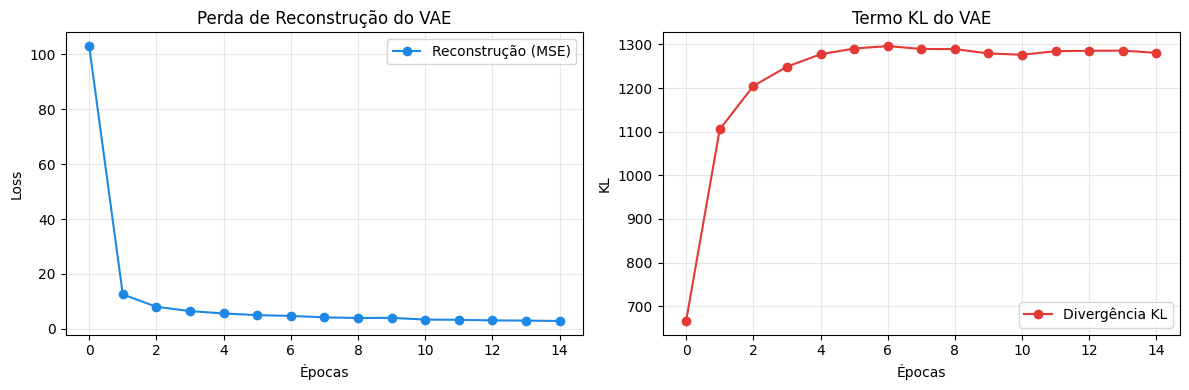

In [6]:
# Treinamento do VAE
epochs_vae = 15
vae_recon_losses = []
vae_kl_losses = []

print("Iniciando treinamento do VAE...")
vae.train()
for epoch in range(epochs_vae):
    epoch_recon, epoch_kl = 0.0, 0.0
    progress_bar = tqdm(train_dataloader, desc=f"VAE - Época {epoch+1}/{epochs_vae}")
    for imgs, _ in progress_bar:
        imgs = imgs.to(device)

        # Forward: reconstrução + parâmetros do posterior
        recon, mu, logvar = vae(imgs)

        # Termo de reconstrução (MSE somado por imagem, médio no batch)
        recon_loss = nn.functional.mse_loss(recon, imgs, reduction="sum") / imgs.size(0)

        # Termo KL com forma fechada (somado por imagem, médio no batch)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / imgs.size(0)

        loss = recon_loss + beta_kl * kl_loss

        # Otimização
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()

        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
        progress_bar.set_postfix(recon=recon_loss.item(), kl=kl_loss.item())

    vae_recon_losses.append(epoch_recon / len(train_dataloader))
    vae_kl_losses.append(epoch_kl / len(train_dataloader))

# Plotar as curvas de reconstrução e KL separadamente
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(vae_recon_losses, color="#1e88e5", marker='o', label="Reconstrução (MSE)")
axs[0].set_title("Perda de Reconstrução do VAE")
axs[0].set_xlabel("Épocas"); axs[0].set_ylabel("Loss"); axs[0].grid(True, alpha=0.3); axs[0].legend()

axs[1].plot(vae_kl_losses, color="#e53935", marker='o', label="Divergência KL")
axs[1].set_title("Termo KL do VAE")
axs[1].set_xlabel("Épocas"); axs[1].set_ylabel("KL"); axs[1].grid(True, alpha=0.3); axs[1].legend()

plt.tight_layout()
plt.show()

### Avaliação das Reconstruções

Antes de prosseguir para o estágio de difusão, é fundamental verificar a qualidade do VAE: o decodificador $\mathcal{D}$ será a "lente" através da qual veremos tudo o que o modelo de difusão gerar. Se as reconstruções forem ruins, nenhum modelo de difusão no espaço latente conseguirá produzir boas imagens — a qualidade do VAE é um **teto superior** para a qualidade final do LDM.

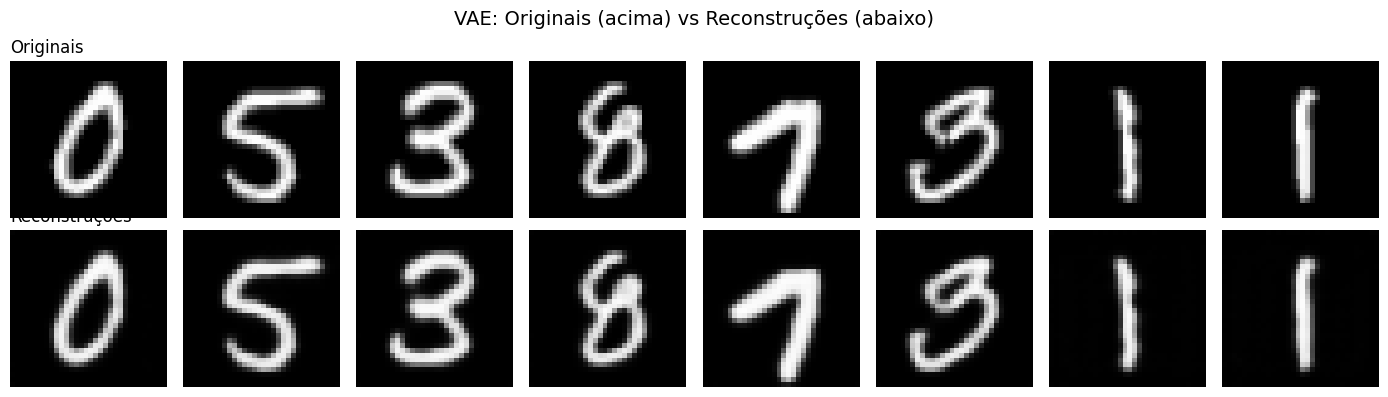

In [7]:
# Comparar imagens originais e reconstruções
vae.eval()
imgs, _ = next(iter(train_dataloader))
imgs = imgs[:8].to(device)

with torch.no_grad():
    recon, _, _ = vae(imgs)

# Desnormalizar de [-1, 1] para [0, 1]
imgs_plot = torch.clamp((imgs + 1.0) / 2.0, 0.0, 1.0).cpu()
recon_plot = torch.clamp((recon + 1.0) / 2.0, 0.0, 1.0).cpu()

fig, axs = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axs[0, i].imshow(imgs_plot[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axs[0, i].axis("off")
    axs[1, i].imshow(recon_plot[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axs[1, i].axis("off")

axs[0, 0].set_title("Originais", loc="left", fontsize=12)
axs[1, 0].set_title("Reconstruções", loc="left", fontsize=12)
plt.suptitle("VAE: Originais (acima) vs Reconstruções (abaixo)", fontsize=14)
plt.tight_layout()
plt.show()

### Normalização do Espaço Latente

O processo de difusão assume que, ao final do processo forward, os dados se tornam ruído Gaussiano padrão $\mathcal{N}(0, \mathbf{I})$. Para que a matemática do DDPM funcione bem, é importante que os latentes tenham **variância aproximadamente unitária**. Embora o termo KL empurre o posterior em direção a $\mathcal{N}(0, \mathbf{I})$, com um $\beta_{KL}$ pequeno essa regularização é fraca e a variância empírica dos latentes não é exatamente $1$. Por isso, calculamos o desvio padrão empírico $\sigma_z$ dos latentes do conjunto de treino e definimos um **fator de escala**:

$$\tilde{z} = \frac{z}{\sigma_z}$$

Onde $z = \mathcal{E}(x)$ é o latente amostrado do posterior e $\tilde{z}$ é o latente normalizado sobre o qual a difusão será aplicada. Na hora de decodificar, basta desfazer a escala: $\hat{x} = \mathcal{D}(\tilde{z} \cdot \sigma_z)$. O Stable Diffusion usa exatamente essa estratégia (o famoso fator `0.18215`).

Como o VAE está congelado a partir de agora, podemos **pré-computar os latentes de todo o dataset uma única vez**. Para cada imagem, amostramos $z \sim q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$ (em vez de usar apenas a média $\mu$), comportamento padrão dos LDMs: a estocasticidade do encoder funciona como uma leve augmentação que torna a difusão mais robusta. Isso também acelera muito o treinamento do segundo estágio, pois não precisamos passar as imagens pelo encoder a cada batch.

In [10]:
# Pré-computar os latentes de todo o conjunto de treino (amostrando do posterior)
vae.eval()
all_latents = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(train_dataloader, desc="Codificando o dataset"):
        mu, logvar = vae.encode(imgs.to(device))
        z = vae.reparameterize(mu, logvar)  # amostra z ~ N(mu, sigma^2)
        all_latents.append(z.cpu())
        all_labels.append(labels)

latents_raw = torch.cat(all_latents, dim=0)
latent_labels = torch.cat(all_labels, dim=0)

# Calcular o fator de escala para variância unitária
sigma_z = latents_raw.std()
scale_factor = 1.0 / sigma_z
latents = latents_raw * scale_factor

print(f"Formato dos latentes: {tuple(latents.shape)}")
print(f"Desvio padrão bruto dos latentes: {sigma_z:.4f}")
print(f"Latentes normalizados -> média: {latents.mean():.4f} | desvio padrão: {latents.std():.4f}")

# DataLoader sobre os latentes pré-computados
latent_dataset = TensorDataset(latents, latent_labels)
latent_dataloader = DataLoader(latent_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

Codificando o dataset: 100%|██████████| 78/78 [00:02<00:00, 36.70it/s]

Formato dos latentes: (9984, 4, 8, 8)
Desvio padrão bruto dos latentes: 0.8027
Latentes normalizados -> média: -1.2559 | desvio padrão: 1.0000


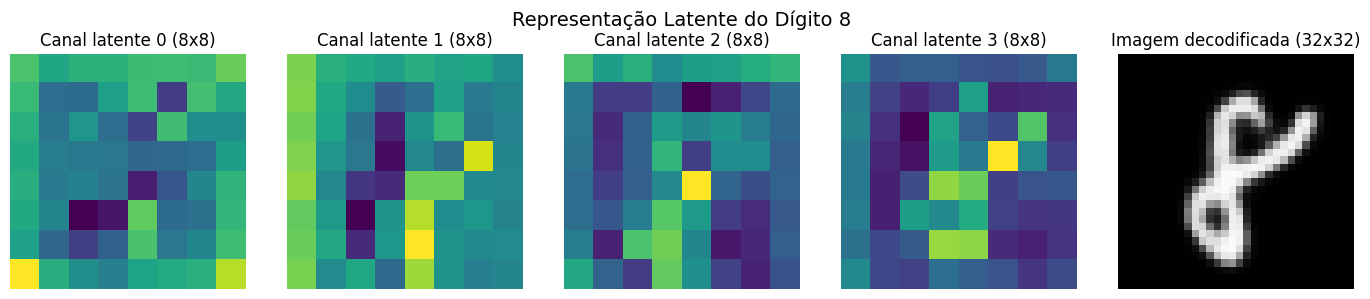

In [11]:
# Função auxiliar: decodificar latentes normalizados de volta para imagens em [0, 1]
@torch.no_grad()
def decode_latents(z_normalized):
    z = z_normalized.to(device) / scale_factor  # desfazer a normalização
    imgs = vae.decode(z)
    imgs = (imgs + 1.0) / 2.0                   # desnormalizar de [-1, 1] para [0, 1]
    return torch.clamp(imgs, 0.0, 1.0).cpu()

# Visualizar os 4 canais do latente de uma imagem e sua decodificação
idx = 0
z_example = latents[idx]
img_decoded = decode_latents(z_example.unsqueeze(0))[0]

fig, axs = plt.subplots(1, 5, figsize=(14, 3))
for c in range(latent_channels):
    axs[c].imshow(z_example[c], cmap="viridis")
    axs[c].set_title(f"Canal latente {c} (8x8)")
    axs[c].axis("off")

axs[4].imshow(img_decoded.squeeze(), cmap="gray", vmin=0, vmax=1)
axs[4].set_title("Imagem decodificada (32x32)")
axs[4].axis("off")

plt.suptitle(f"Representação Latente do Dígito {latent_labels[idx].item()}", fontsize=14)
plt.tight_layout()
plt.show()

## Estágio 2: Difusão no Espaço Latente

Agora aplicaremos exatamente o mesmo formalismo do DDPM visto nos notebooks anteriores, mas substituindo a imagem $x$ pelo latente normalizado $z$. O processo forward adiciona ruído Gaussiano gradualmente ao longo de $T$ passos:

$$q(z_t | z_0) = \mathcal{N}(z_t; \sqrt{\bar{\alpha}_t} z_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

Onde $z_0 = \tilde{z}$ é o latente limpo, $\alpha_t = 1 - \beta_t$, $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$ e $\beta_t$ é o schedule de variância. A propriedade de amostragem direta continua válida:

$$z_t = \sqrt{\bar{\alpha}_t} z_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, \quad \text{com } \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

A única diferença prática é a dimensionalidade: em vez de difundir tensores $1 \times 32 \times 32$ (1024 valores), difundimos tensores $4 \times 8 \times 8$ (256 valores). Usaremos $T = 500$ passos com um schedule linear.

In [15]:
# Hiperparâmetros da difusão
n_steps = 500
beta_start = 1e-4
beta_end = 0.02

# Definição do Schedule e Coeficientes Matemáticos
betas = torch.linspace(beta_start, beta_end, n_steps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Variância teórica do passo reverso (q(z_{t-1} | z_t, z_0))
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def q_sample(z_0, t, noise=None):
    """Amostra z_t a partir de z_0 no passo t."""
    noise = torch.randn_like(z_0) if noise is None else noise
    shape = (t.shape[0],) + (1,) * (z_0.ndim - 1)
    alpha_t = sqrt_alphas_cumprod[t].reshape(shape)
    sigma_t = sqrt_one_minus_alphas_cumprod[t].reshape(shape)
    return alpha_t * z_0 + sigma_t * noise

### Visualização do Processo Forward no Espaço Latente

Uma pergunta interessante: **como "enxergamos" a difusão acontecendo no espaço latente?** O latente em si é um tensor abstrato de $4 \times 8 \times 8$, mas podemos usar o decodificador $\mathcal{D}$ como uma janela para o espaço de pixels: em cada passo $t$, decodificamos o latente ruidoso $z_t$ e observamos a imagem correspondente.

Note que o decodificador nunca foi treinado com latentes ruidosos, então as decodificações intermediárias produzem imagens degradadas e sem sentido — exatamente como esperado: a estrutura do dígito vai sendo destruída no espaço latente.

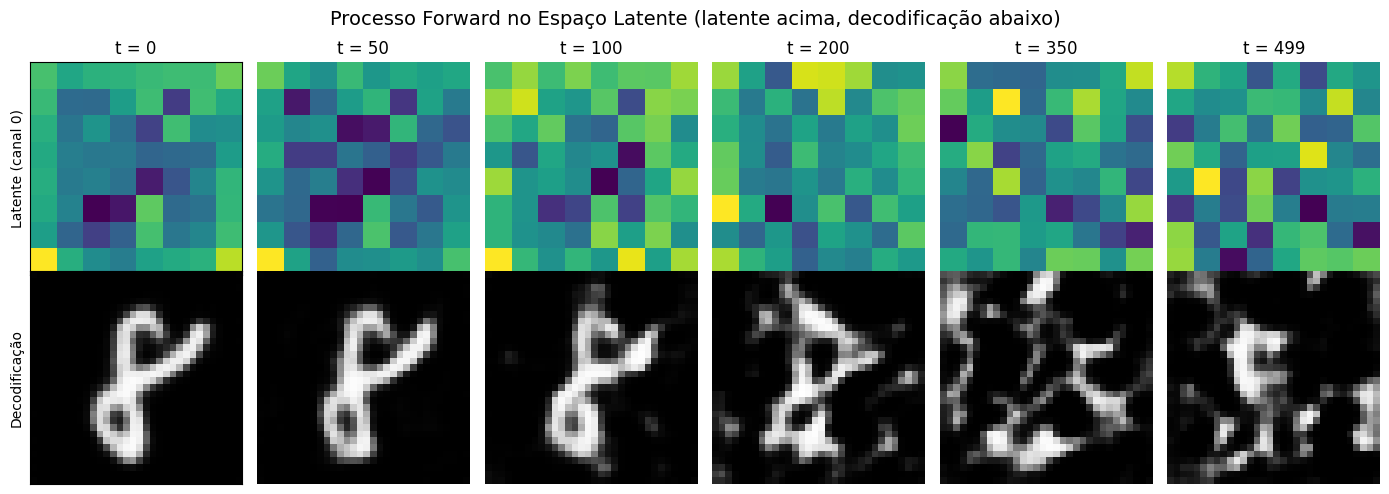

In [16]:
# Difundir o latente de uma imagem e decodificar em vários passos t
steps_to_plot = [0, 50, 100, 200, 350, 499]
z_0 = latents[0].unsqueeze(0).to(device)

fig, axs = plt.subplots(2, len(steps_to_plot), figsize=(14, 5))

for i, t_val in enumerate(steps_to_plot):
    t_tensor = torch.tensor([t_val], device=device, dtype=torch.long)
    z_t = q_sample(z_0, t_tensor)

    # Linha 1: primeiro canal do latente ruidoso
    axs[0, i].imshow(z_t[0, 0].cpu(), cmap="viridis")
    axs[0, i].set_title(f"t = {t_val}")
    axs[0, i].axis("off")

    # Linha 2: imagem decodificada do latente ruidoso
    img_t = decode_latents(z_t)[0]
    axs[1, i].imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1)
    axs[1, i].axis("off")

axs[0, 0].set_ylabel("Latente (canal 0)")
axs[0, 0].axis("on"); axs[0, 0].set_xticks([]); axs[0, 0].set_yticks([])
axs[1, 0].set_ylabel("Decodificação")
axs[1, 0].axis("on"); axs[1, 0].set_xticks([]); axs[1, 0].set_yticks([])

plt.suptitle("Processo Forward no Espaço Latente (latente acima, decodificação abaixo)", fontsize=14)
plt.tight_layout()
plt.show()

### Arquitetura do Modelo (U-Net Latente)

A rede de desruído $\epsilon_\theta(z_t, t, y)$ é uma **U-Net** que opera sobre os latentes de $4 \times 8 \times 8$. Por trabalhar em uma resolução tão pequena, ela é significativamente menor e mais rápida que a U-Net que usamos sobre pixels no notebook de Guidance.

A rede recebe três entradas:

- **Latente ruidoso** $z_t \in \mathbb{R}^{B \times 4 \times 8 \times 8}$, processado pelas convoluções.
- **Passo temporal** $t$, mapeado por *Sinusoidal Position Embeddings* seguidos de um MLP, e somado aos canais ocultos dentro dos blocos residuais.
- **Rótulo de classe** $y \in \{0, \dots, 9\}$, mapeado por uma camada `nn.Embedding`. O índice $10$ é reservado para a **classe nula** $\emptyset$ (geração incondicional), que será essencial para o Classifier-Free Guidance mais adiante.

O fluxo de dimensões é: o latente entra em $8 \times 8$, desce para $4 \times 4$ no caminho de contração, passa pelos blocos intermediários e retorna para $8 \times 8$ no caminho de expansão, com uma *skip connection* concatenando as ativações de mesma resolução. A saída tem o mesmo formato da entrada ($B \times 4 \times 8 \times 8$), pois a rede prevê o ruído $\epsilon$ contido no latente.

In [17]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2

        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / (half_dim - 1)
        )

        emb = time[:, None] * freqs[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)

        return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(groups, out_ch),
            nn.GELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(groups, out_ch),
            nn.GELU()
        )
        self.res_conv = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

In [18]:
class LatentUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=4, hidden_dim=64, num_classes=10):
        super().__init__()

        time_dim = hidden_dim * 4
        self.null_class = num_classes

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.class_mlp = nn.Sequential(
            nn.Embedding(num_classes + 1, time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.down1 = ResBlock(hidden_dim, hidden_dim * 2, time_dim)
        self.downsample1 = Downsample(hidden_dim * 2)

        self.mid1 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)
        self.mid2 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)

        self.upsample1 = Upsample(hidden_dim * 2)
        self.up1 = ResBlock(hidden_dim * 4, hidden_dim, time_dim)

        self.out = nn.Conv2d(hidden_dim, out_channels, 1)

    def forward(self, z, t, y):
        emb = self.time_mlp(t) + self.class_mlp(y)

        z = self.init_conv(z)             # B x 64 x 8 x 8

        h1 = self.down1(z, emb)           # B x 128 x 8 x 8
        z = self.downsample1(h1)          # B x 128 x 4 x 4

        z = self.mid1(z, emb)             # B x 128 x 4 x 4
        z = self.mid2(z, emb)             # B x 128 x 4 x 4

        z = self.upsample1(z)             # B x 128 x 8 x 8
        z = torch.cat([z, h1], dim=1)     # B x 256 x 8 x 8
        z = self.up1(z, emb)              # B x 64 x 8 x 8

        return self.out(z)                # B x 4 x 8 x 8

### Treinamento

O treinamento segue a receita padrão do DDPM, agora sobre os latentes pré-computados. Em cada iteração:

1. Amostramos um batch de latentes limpos $z_0$ com seus rótulos $y$.
2. Aplicamos **Label Dropout**: com probabilidade de $15\%$, o rótulo $y$ é substituído pela classe nula $\emptyset$ (índice 10). Isso força o modelo a aprender simultaneamente as predições condicional e incondicional, requisito do Classifier-Free Guidance.
3. Sorteamos um passo temporal $t \sim \text{Uniforme}(\{0, \dots, T-1\})$ e um ruído $\epsilon \sim \mathcal{N}(0, \mathbf{I})$.
4. Computamos $z_t = \sqrt{\bar{\alpha}_t} z_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ e minimizamos a perda:

$$\mathcal{L}(\theta) = \mathbb{E}_{t, z_0, \epsilon, y} \left[ \| \epsilon - \epsilon_\theta(z_t, t, y) \|^2 \right]$$

Onde $\epsilon_\theta$ é a U-Net latente. Note como cada época é rápida: a rede processa tensores 4 vezes menores que as imagens originais.

In [19]:
# Instanciar modelo de difusão latente, otimizador e função de perda
ldm_model = LatentUNet(in_channels=latent_channels, out_channels=latent_channels).to(device)
optimizer_ldm = optim.AdamW(ldm_model.parameters(), lr=1e-3)
criterion_ldm = nn.MSELoss()

n_params = sum(p.numel() for p in ldm_model.parameters())
print(f"Parâmetros da U-Net latente: {n_params:,}")

Parâmetros da U-Net latente: 1,881,924


In [20]:
# Treinamento do Modelo de Difusão Latente
epochs_ldm = 30
ldm_losses = []

print("Iniciando treinamento da Difusão Latente...")
ldm_model.train()
for epoch in range(epochs_ldm):
    epoch_loss = 0
    progress_bar = tqdm(latent_dataloader, desc=f"Difusão Latente - Época {epoch+1}/{epochs_ldm}")
    for z_0, labels in progress_bar:
        z_0, labels = z_0.to(device), labels.to(device)

        # Aplicar Label Dropout de 15%
        mask = torch.rand(labels.shape, device=device) < 0.15
        labels_cond = labels.clone()
        labels_cond[mask] = 10  # índice 10 representa a classe nula

        # Amostrar t e ruído
        t = torch.randint(0, n_steps, (z_0.size(0),), device=device).long()
        noise = torch.randn_like(z_0)
        z_t = q_sample(z_0, t, noise)

        # Otimização
        optimizer_ldm.zero_grad()
        pred_noise = ldm_model(z_t, t, labels_cond)
        loss = criterion_ldm(pred_noise, noise)
        loss.backward()
        optimizer_ldm.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    ldm_losses.append(epoch_loss / len(latent_dataloader))

Iniciando treinamento da Difusão Latente...


Difusão Latente - Época 30/30: 100%|██████████| 78/78 [00:01<00:00, 55.69it/s, loss=0.0831]


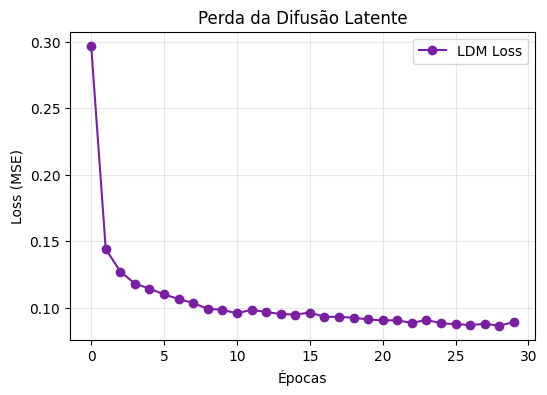

In [21]:
# Plotar curva de perda da difusão latente
plt.figure(figsize=(6, 4))
plt.plot(ldm_losses, color="#7b1fa2", marker='o', label="LDM Loss")
plt.title("Perda da Difusão Latente")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Geração (Amostragem)

A amostragem de um LDM acontece em duas etapas:

1. **Difusão reversa no espaço latente:** partimos de ruído puro $z_T \sim \mathcal{N}(0, \mathbf{I})$ com formato $4 \times 8 \times 8$ e executamos a cadeia reversa de $t = T-1$ até $t = 0$:

$$z_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( z_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(z_t, t, y) \right) + \sigma_t \eta$$

Onde $\eta \sim \mathcal{N}(0, \mathbf{I})$ se $t > 0$ (e $\eta = 0$ no último passo) e $\sigma_t^2$ é a variância do posterior do passo reverso.

2. **Decodificação:** uma única passagem do latente final $z_0$ pelo decodificador, $\hat{x} = \mathcal{D}(z_0 \cdot \sigma_z)$, produz a imagem de $32 \times 32$.

Repare na economia: os 500 passos iterativos acontecem inteiramente no espaço pequeno; o decodificador (a parte que toca o espaço de pixels) roda **uma única vez**. Primeiro geraremos amostras incondicionais, passando a classe nula $\emptyset$ para o modelo.

In [22]:
@torch.no_grad()
def p_sample_latent(model, y, num_samples=8):
    """Executa a cadeia reversa completa no espaço latente e retorna z_0."""
    model.eval()

    # Iniciar com ruído puro no formato do latente
    z = torch.randn(num_samples, latent_channels, 8, 8, device=device)

    for t in reversed(range(n_steps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Prever o ruído no latente
        eps = model(z, t_tensor, y)

        # Coeficientes para o passo reverso
        a = alphas[t]
        b = betas[t]
        sqrt_oma = sqrt_one_minus_alphas_cumprod[t]

        mean = (z - b * eps / sqrt_oma) / torch.sqrt(a)

        if t == 0:
            z = mean
        else:
            z = mean + torch.sqrt(posterior_variance[t]) * torch.randn_like(z)

    return z

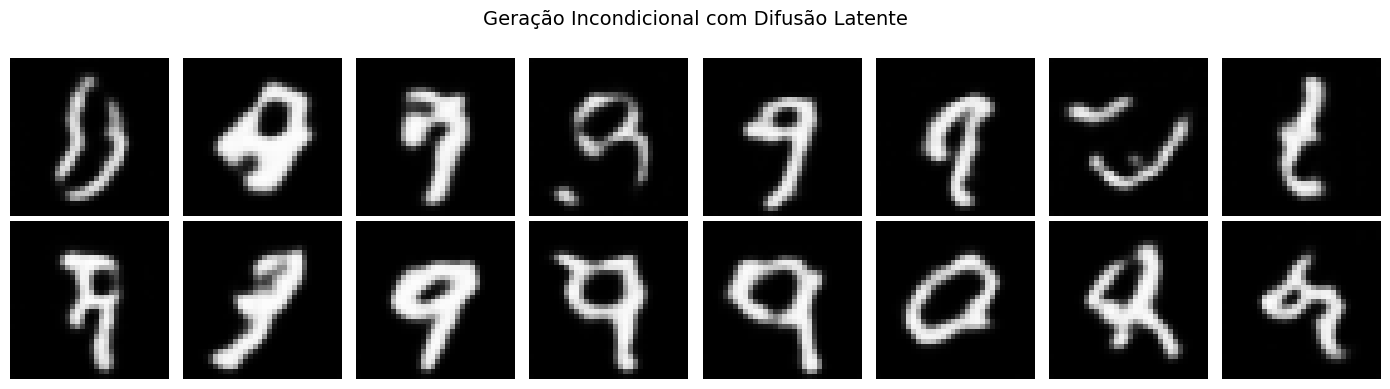

In [23]:
# Geração incondicional: 16 amostras usando a classe nula
num_samples = 16
y_null = torch.full((num_samples,), 10, dtype=torch.long, device=device)

z_generated = p_sample_latent(ldm_model, y_null, num_samples=num_samples)
imgs_generated = decode_latents(z_generated)

fig, axs = plt.subplots(2, 8, figsize=(14, 4))
for i in range(num_samples):
    ax = axs[i // 8, i % 8]
    ax.imshow(imgs_generated[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

plt.suptitle("Geração Incondicional com Difusão Latente", fontsize=14)
plt.tight_layout()
plt.show()

### Visualizando o Processo Reverso com o Decoder

Esta é uma das visualizações mais reveladoras de um LDM. Durante a amostragem, salvamos o latente intermediário $z_t$ em alguns passos selecionados e usamos o decodificador para responder: **"se parássemos a difusão agora, que imagem este latente representaria?"**

Exibiremos duas linhas: a de cima mostra o primeiro canal do latente $z_t$ (o espaço onde a difusão de fato acontece) e a de baixo mostra a imagem $\mathcal{D}(z_t \cdot \sigma_z)$ correspondente. Observe como, no início, o decodificador transforma ruído em manchas incoerentes, e como a estrutura do dígito emerge gradualmente conforme $t \to 0$.

In [24]:
@torch.no_grad()
def p_sample_latent_steps(model, y, num_samples=1, plot_steps=None):
    """Executa a cadeia reversa salvando os latentes intermediários nos passos selecionados."""
    model.eval()

    z = torch.randn(num_samples, latent_channels, 8, 8, device=device)
    saved_steps = {}

    for t in reversed(range(n_steps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Salvar o estado ANTES do passo de denoising se for um dos passos selecionados
        if plot_steps is not None and t in plot_steps:
            saved_steps[t] = z.detach().cpu().clone()

        eps = model(z, t_tensor, y)

        a = alphas[t]
        b = betas[t]
        sqrt_oma = sqrt_one_minus_alphas_cumprod[t]

        mean = (z - b * eps / sqrt_oma) / torch.sqrt(a)

        if t == 0:
            z = mean
        else:
            z = mean + torch.sqrt(posterior_variance[t]) * torch.randn_like(z)

    # Salvar o resultado final z_0
    if plot_steps is not None and 0 in plot_steps:
        saved_steps[0] = z.detach().cpu().clone()

    return saved_steps

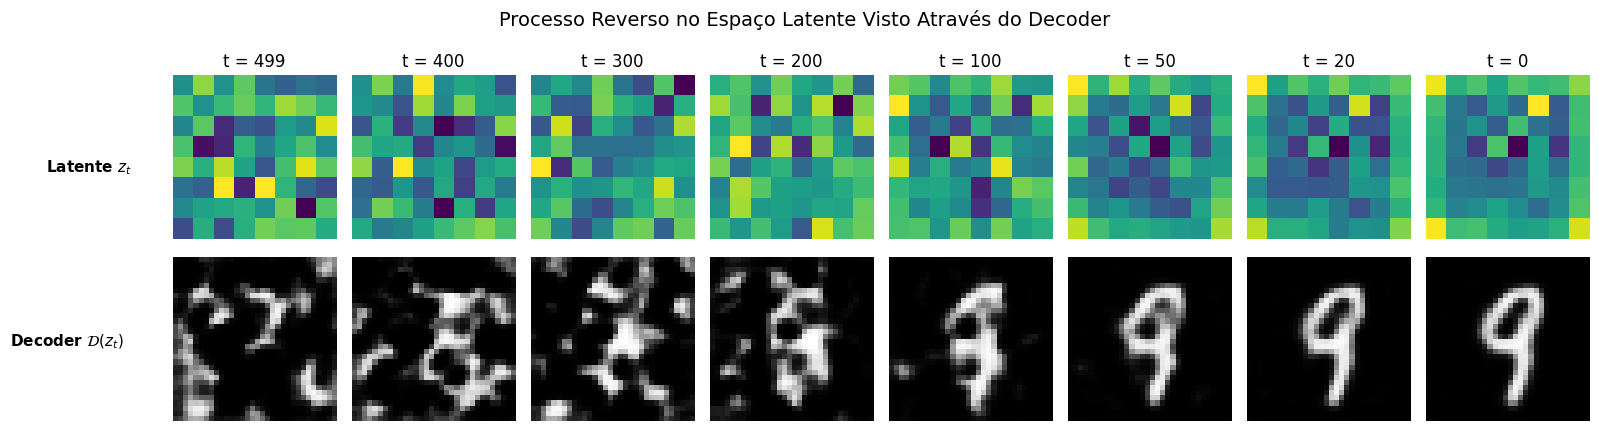

In [25]:
# Escolher 8 passos para visualizar (do ruído inicial ao latente final)
plot_steps = [499, 400, 300, 200, 100, 50, 20, 0]

torch.manual_seed(7)
y_null = torch.full((1,), 10, dtype=torch.long, device=device)
saved_latents = p_sample_latent_steps(ldm_model, y_null, num_samples=1, plot_steps=plot_steps)

fig, axs = plt.subplots(2, len(plot_steps), figsize=(16, 4.5))

for col_idx, t in enumerate(plot_steps):
    z_t = saved_latents[t]

    # Linha 1: primeiro canal do latente intermediário (4 x 8 x 8)
    axs[0, col_idx].imshow(z_t[0, 0], cmap="viridis")
    axs[0, col_idx].set_title(f"t = {t}")
    axs[0, col_idx].axis("off")

    # Linha 2: imagem decodificada do latente intermediário
    img_t = decode_latents(z_t)[0]
    axs[1, col_idx].imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1)
    axs[1, col_idx].axis("off")

axs[0, 0].text(-2.5, 4, "Latente $z_t$", fontsize=11, fontweight="bold", va="center", ha="right")
axs[1, 0].text(-10, 16, "Decoder $\\mathcal{D}(z_t)$", fontsize=11, fontweight="bold", va="center", ha="right")

plt.suptitle("Processo Reverso no Espaço Latente Visto Através do Decoder", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### Classifier-Free Guidance (CFG)

Graças ao Label Dropout aplicado durante o treinamento, nosso modelo $\epsilon_\theta$ sabe operar tanto condicionado a um dígito $y$ quanto incondicionalmente (com a classe nula $\emptyset$). O **Classifier-Free Guidance** explora isso na amostragem: em cada passo, computamos as duas predições e extrapolamos linearmente na direção da condição:

$$\tilde{\epsilon}_\theta(z_t, t, y) = \epsilon_\theta(z_t, t, \emptyset) + s \left( \epsilon_\theta(z_t, t, y) - \epsilon_\theta(z_t, t, \emptyset) \right)$$

Onde $s \ge 0$ é a escala de guidance: $s = 0$ recupera a geração incondicional, $s = 1$ corresponde à geração condicional clássica e $s > 1$ amplifica os traços característicos da classe alvo. É exatamente este mecanismo, aplicado no espaço latente, que o Stable Diffusion usa quando você ajusta o parâmetro *guidance scale* de um prompt de texto — com a diferença de que lá a condição $y$ é um embedding de texto em vez de um rótulo de classe.

In [26]:
@torch.no_grad()
def p_sample_latent_cfg(model, y_target, guidance_scale=1.0, num_samples=8):
    """Amostragem no espaço latente com Classifier-Free Guidance."""
    model.eval()

    # Iniciar com ruído puro no espaço latente
    z = torch.randn(num_samples, latent_channels, 8, 8, device=device)

    # Rótulo condicional e rótulo incondicional (10)
    y_cond = torch.full((num_samples,), y_target, dtype=torch.long, device=device)
    y_uncond = torch.full((num_samples,), 10, dtype=torch.long, device=device)

    for t in reversed(range(n_steps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Predição de ruído condicional e incondicional
        eps_cond = model(z, t_tensor, y_cond)
        eps_uncond = model(z, t_tensor, y_uncond)

        # Combinar as predições usando a escala de guidance s
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        # Coeficientes para o passo reverso
        a = alphas[t]
        b = betas[t]
        sqrt_oma = sqrt_one_minus_alphas_cumprod[t]

        mean = (z - b * eps / sqrt_oma) / torch.sqrt(a)

        if t == 0:
            z = mean
        else:
            z = mean + torch.sqrt(posterior_variance[t]) * torch.randn_like(z)

    return z

Gerando dígitos com CFG escala s = 0.0...
Gerando dígitos com CFG escala s = 1.0...
Gerando dígitos com CFG escala s = 3.0...
Gerando dígitos com CFG escala s = 5.0...
Gerando dígitos com CFG escala s = 10.0...


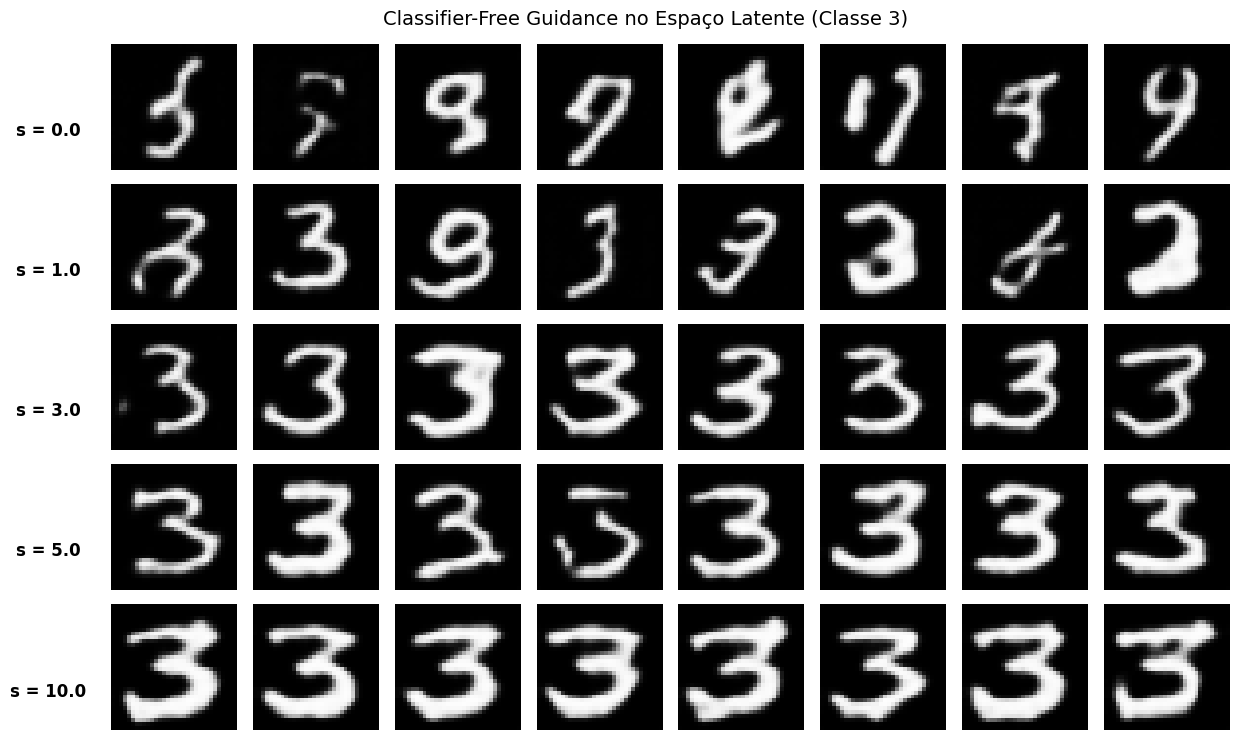

In [27]:
# Gerar o dígito 3 com diferentes escalas de guidance
y_target = 3
cfg_scales = [0.0, 1.0, 3.0, 5.0, 10.0]

fig, axs = plt.subplots(len(cfg_scales), 8, figsize=(12, 7.5))

for row_idx, scale in enumerate(cfg_scales):
    print(f"Gerando dígitos com CFG escala s = {scale}...")
    z_samples = p_sample_latent_cfg(ldm_model, y_target=y_target, guidance_scale=scale, num_samples=8)
    samples = decode_latents(z_samples).numpy().reshape(8, 32, 32)

    for col_idx in range(8):
        ax = axs[row_idx, col_idx]
        ax.imshow(samples[col_idx], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"s = {scale}", x=-0.5, y=0.2, fontsize=12, fontweight="bold")

plt.suptitle(f"Classifier-Free Guidance no Espaço Latente (Classe {y_target})", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

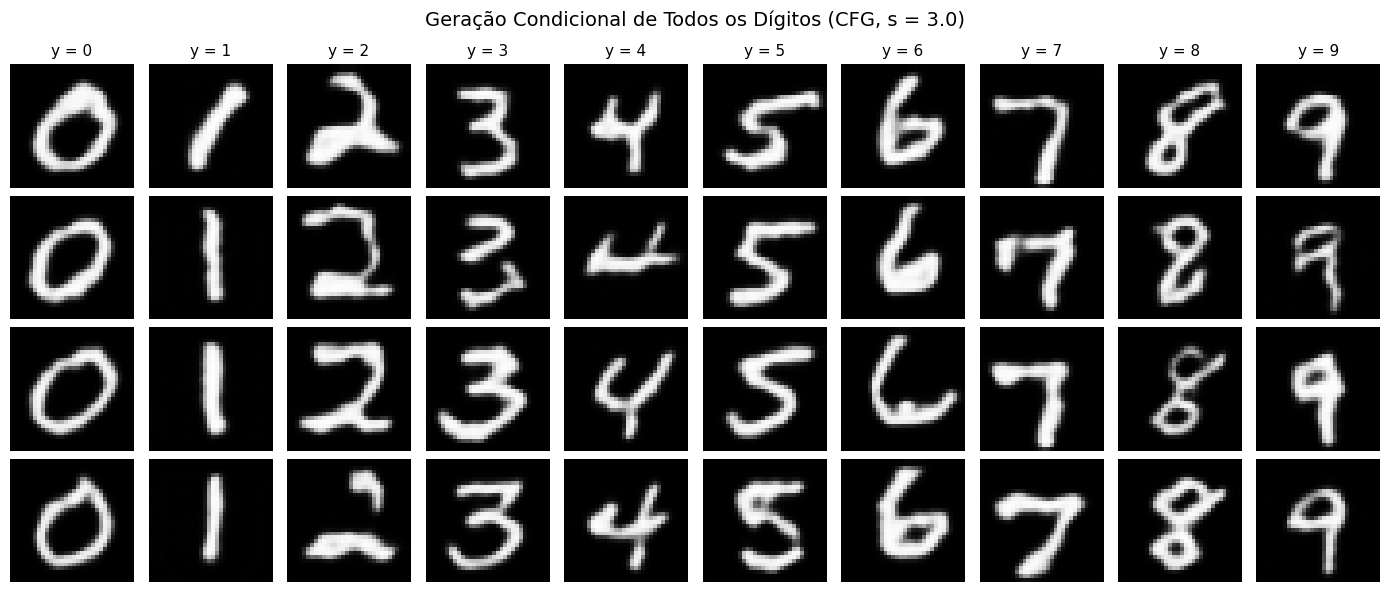

In [28]:
# Gerar todos os dígitos de 0 a 9 com uma escala de guidance fixa
guidance_scale = 3.0
n_rows = 4

fig, axs = plt.subplots(n_rows, 10, figsize=(14, 6))

for digit in range(10):
    z_samples = p_sample_latent_cfg(ldm_model, y_target=digit, guidance_scale=guidance_scale, num_samples=n_rows)
    samples = decode_latents(z_samples).numpy().reshape(n_rows, 32, 32)

    for row_idx in range(n_rows):
        ax = axs[row_idx, digit]
        ax.imshow(samples[row_idx], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if row_idx == 0:
            ax.set_title(f"y = {digit}", fontsize=11)

plt.suptitle(f"Geração Condicional de Todos os Dígitos (CFG, s = {guidance_scale})", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## Exercícios

### Exercício 1
O número de canais do latente controla o equilíbrio entre compressão e fidelidade. Treine novamente o VAE com `latent_channels = 2` e depois com `latent_channels = 8`, retreinando também o modelo de difusão em cada caso. Compare a qualidade das reconstruções do VAE e das amostras finais geradas. O que acontece quando o gargalo é apertado demais? E quando é largo demais?

### Exercício 2
Meça o tempo de uma amostragem completa (por exemplo, com `%%time` ou `time.time()`) usando a U-Net latente deste notebook e compare com o tempo de amostragem da U-Net em espaço de pixels do notebook de Diffusion Guidance, usando o mesmo número de passos $T$ e o mesmo número de amostras. Calcule a razão de aceleração obtida e relacione o resultado com a diferença de dimensionalidade entre os dois espaços ($1 \times 32 \times 32$ vs $4 \times 8 \times 8$).

### Exercício 3
Substitua o MNIST pelo **Fashion-MNIST** (basta trocar `datasets.MNIST` por `datasets.FashionMNIST`), que possui as mesmas dimensões de imagem. Retreine os dois estágios e avalie os resultados. O VAE com 4 canais latentes ainda é suficiente para capturar as texturas das roupas, que são mais ricas que os traços dos dígitos? Experimente também variar a escala de guidance na geração condicional das 10 classes de roupas.

### Exercício 4
Aumente progressivamente o peso do termo KL no treinamento do VAE (por exemplo, `beta_kl = 1e-2` e depois `beta_kl = 1e-1`) e reavalie as reconstruções. Como o $\beta_{KL}$ afeta o equilíbrio entre fidelidade da reconstrução e regularidade do espaço latente? Verifique também o desvio padrão bruto $\sigma_z$ dos latentes em cada caso e relacione-o com a intensidade da regularização imposta pela divergência KL.